In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [9]:
import pandas as pd
print("\nLoading Dataset...")
dataset=pd.read_csv("spam.csv",encoding="latin-1")
print("Dataset Loaded Successfully")


Loading Dataset...
Dataset Loaded Successfully


In [10]:
print("\nDataset Information")
dataset.info()
print("\nDataset Shape")
print(dataset.shape)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

Dataset Shape
(5572, 5)


In [16]:
print("\nEmail Category Count")
print(dataset["v1"].value_counts())


Email Category Count
v1
ham     4825
spam     747
Name: count, dtype: int64


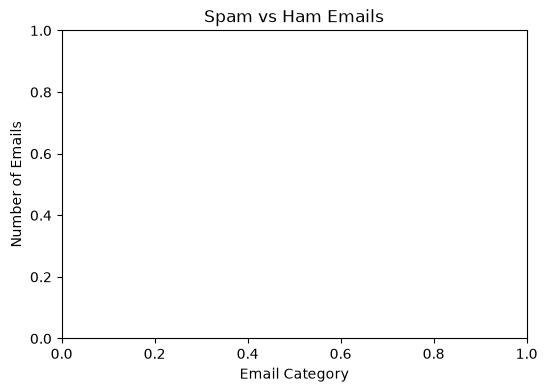

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(X="v1",data=dataset)
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.show()

In [20]:
x=dataset["v2"]
y=dataset["v1"]

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print("\nTraining Samples:",len(x_train))
print("Testing Samples:",len(x_test))
                            


Training Samples: 4457
Testing Samples: 1115


In [22]:
print("\nConverting Text into Numerical Features...")
cv=CountVectorizer()
x_train=cv.fit_transform(x_train)
x_test=cv.transform(x_test)
print("Conversion Completed")
print("Training Data Shape:",x_train.shape)
print("Testing Data Shape:",x_test.shape)


Converting Text into Numerical Features...
Conversion Completed
Training Data Shape: (4457, 7735)
Testing Data Shape: (1115, 7735)


In [24]:
print("\nTraining SVM Model..")
classifier=SVC(kernel="linear")
classifier.fit(x_train,y_train)
print("Model Training Completed")



Training SVM Model..
Model Training Completed


In [25]:
print("\nPredicting Test Data....")
y_pred=classifier.predict(x_test)
print("Prediction Completed")


Predicting Test Data....
Prediction Completed


In [26]:
accuracy=accuracy_score(y_test,y_pred)
print("MODEL ACCURACY")
print("Accuracy=",accuracy)
print("Accuracy={:2f}%",format(accuracy*100))

MODEL ACCURACY
Accuracy= 0.979372197309417
Accuracy={:2f}% 97.9372197309417



Confusion Matrix
[[961   4]
 [ 19 131]]


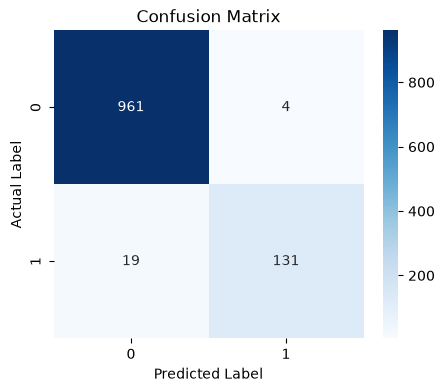

In [28]:
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix")
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [31]:
print("\n Classification Report")
print(classification_report(y_test,y_pred))


 Classification Report
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [41]:
print("Sample Predictions")
sample_messages=["Congratulations! You have won a free iPhone.click here to claim","Hi,shall we meet tomorrow at 10AM?","URGENT! Your bank account has been suspended verify immediately.",
           "Happy Birthday! Have a wonderful day.",
           "You have won Rs.50000 cash prize.call now"]
sample_data=cv.transform(sample_messages)
prediction=classifier.predict(sample_data)
for messages,prediction in zip(sample_messages,prediction):
    print("\nMessage:")
    print(messages)
    print("prediction",prediction)

Sample Predictions

Message:
Congratulations! You have won a free iPhone.click here to claim
prediction spam

Message:
Hi,shall we meet tomorrow at 10AM?
prediction ham

Message:
URGENT! Your bank account has been suspended verify immediately.
prediction spam

Message:
Happy Birthday! Have a wonderful day.
prediction ham

Message:
You have won Rs.50000 cash prize.call now
prediction spam
